# Matplotlib : Format_Chart 

**Methods**
- fig, ax = plt.subplots(rows, columns) ~ how many rows and columns you need for plotting
- fig.tight_layout()


In [1]:
# Import libraries
from datasets import load_dataset
import ast
import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
raw = load_dataset('lukebarousse/data_jobs')
data = raw['train'].to_pandas()
df = data.copy()

# Data Cleaning 
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

**Example 1**
- fig, ax = plt.subplots()

*job Count using value_count() function*

In [2]:
df_job_count = df['job_title_short'].value_counts()
df_job_count

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64

*job type*

In [3]:
df_job_type = df['job_schedule_type'].value_counts().head(3)
df_job_type

job_schedule_type
Full-time     701727
Contractor     34793
Internship      8742
Name: count, dtype: int64

*Using fig, ax = plt.subplots() to plot both above job count and job type in the same visual*

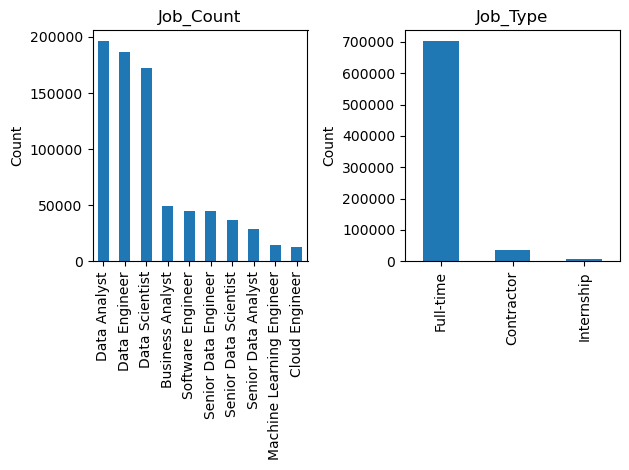

In [4]:
fig, ax = plt.subplots(1,2)

df_job_count.plot(kind='bar',ax=ax[0])
df_job_type.plot(kind='bar',ax=ax[1])

ax[0].set_xlabel('')
ax[0].set_ylabel('Count')
ax[0].set_title('Job_Count')

ax[1].set_xlabel('')
ax[1].set_ylabel('Count')
ax[1].set_title('Job_Type')

fig.tight_layout()


**Example 2**

*Using explode() method to find the top 5 skills for each job*

In [5]:
df_explode = df.explode('job_skills').copy()
df_explode

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,r,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,python,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,sql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,nosql,"{'analyst_tools': ['power bi', 'tableau'], 'pr..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,kafka,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,kubernetes,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,docker,"{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."
785740,Software Engineer,AWS System Analyst,India,melalui Trigyn,Pekerjaan tetap,False,India,2023-03-13 06:16:31,False,False,India,NaN,NaN,NaN,Trigyn,aws,"{'cloud': ['aws'], 'other': ['flow']}"


In [6]:
df_skills =df_explode.groupby(['job_skills','job_title_short']).size()
df_skills = df_skills.reset_index(name='skill_count')
df_skills = df_skills.sort_values('skill_count',ascending=False)
df_skills

,job_skills,job_title_short,skill_count
1480,python,Data Scientist,113711
1822,sql,Data Engineer,113130
1479,python,Data Engineer,108022
1821,sql,Data Analyst,92428
1823,sql,Data Scientist,78982
...,...,...,...
2173,webex,Senior Data Scientist,1
293,codecommit,Business Analyst,1
2233,xamarin,Machine Learning Engineer,1
1087,mlr,Machine Learning Engineer,1


In [7]:
job_titles =['Data Analyst','Data Engineer','Data Scientist']

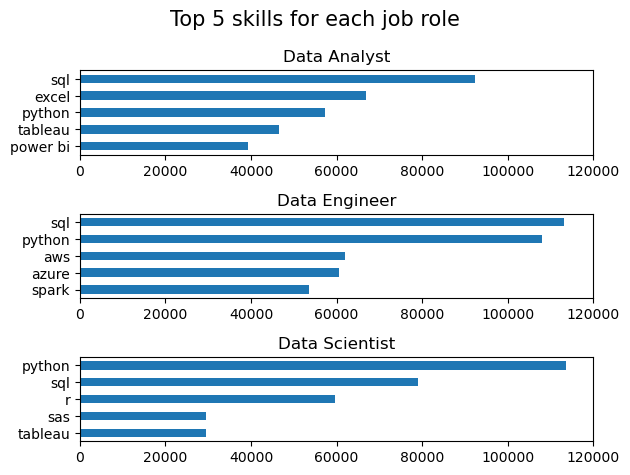

In [8]:
fig, ax = plt.subplots(3,1)

for i, job_title in enumerate(job_titles):
    df_plot =df_skills[df_skills['job_title_short']==job_title].head(5)
    df_plot.plot(kind='barh',x='job_skills',y='skill_count',title=job_title,ax=ax[i])
    ax[i].invert_yaxis()
    ax[i].set_ylabel('')
    ax[i].legend('').set_visible(False)
    ax[i].set_xlim(0, 120000)

fig.suptitle('Top 5 skills for each job role',fontsize=15)
fig.tight_layout()